# Brain - ANN similarity

In [1]:
import pandas as pd
import numpy as np
from lstnn.parcellation import Parcellation
import matplotlib.pyplot as plt
import seaborn as sns

# parameters
pe_desc = "2dpe"
fmethod = "crossnobis" # "crossnobis"
amethod = "euclidean" #  "euclidean"
cmethod = "corr" 
epoch = 4000
n_perms = 10000
atlas = "Glasser"

if atlas == "Glasser":
    cortex = 'Glasser'
    cortex_res = None
    scale = 1
elif atlas == "Schaefer":
    cortex = 'Schaefer'
    cortex_res = 400
    scale = 1

parc = Parcellation(cortex=cortex, cortex_res=cortex_res, scale=scale)

df_list = []
in_file = f"../processed_data/pe-{pe_desc}"
in_file += f"_fmethod-{fmethod}_amethod-{amethod}_cmethod-{cmethod}"
in_file += f"_epoch-{epoch}_nperms-{n_perms}"

#df_all = pd.read_csv(in_file+".csv")
df = pd.read_csv(in_file+"_stats.csv")
df.head()

,stat,permutation,compare_method,model,parcel,it,pe,fmethod,cmethod,amethod,epoch,p_FDR,percentile,network
0,0.015285,False,corr,pe_layer0,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.7336,NaN
1,0.029015,False,corr,pe_layer1,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.8654,NaN
2,-0.005313,False,corr,pe_layer2,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.4318,NaN
3,0.014045,False,corr,pe_layer3,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.7065,NaN
4,0.015040,False,corr,pe_avg,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.6997,NaN


## Table for significant results

In [2]:
data = df.loc[((df.model == "pe_avg") | (df.model == "attn_out_avg"))
              & (df.p_FDR < 0.05)]
results = data[["model", "parcel", "network", "stat", "p_FDR"]]

results.replace("pe_avg", "PE", inplace=True)
results.replace("attn_out_avg", "Attention", inplace=True)
results = results.sort_values(by=["model", "network"])
results["stat"] = np.round(results["stat"],3)
results["p_FDR"] = np.round(results["p_FDR"],4)
results.head()

/tmp/ipykernel_1210821/3025181846.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results.replace("pe_avg", "PE", inplace=True)
/tmp/ipykernel_1210821/3025181846.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results.replace("attn_out_avg", "Attention", inplace=True)


,model,parcel,network,stat,p_FDR
1239,Attention,R_8Av_ROI,Default,0.108,0.0000
2499,Attention,R_PGs_ROI,Default,0.141,0.0000
5199,Attention,L_PGs_ROI,Default,0.089,0.0499
1389,Attention,R_a47r_ROI,Frontoparietal,0.128,0.0212
1704,Attention,R_s6-8_ROI,Frontoparietal,0.102,0.0212


### Incorporate noise ceiling results

In [4]:
nc_perms = 1000
noise_ceilings = []

# functions
def spearmanbrown(rho, k):
  """adjust the correlation coefficient r for test length by scaling by k, which
  defines the full length (e.g., if the full length is twice of what r was 
  calculated for, k=2)."""
  # SB is undefined if r<0
  thisr = rho * np.array(rho > 0., dtype='float')
  thisr = (k * thisr) / (1 + (k - 1) * thisr)
  return thisr


def summary_stats(x):
    """Return mean, 5th percentile, and 95th percentile of an array."""
    x = np.asarray(x)
    return np.mean(x), np.percentile(x, 5), np.percentile(x, 95)


# load relevant noise ceilings
results["noise_ceiling"] = "n/a"
results["% noise ceiling"] = 0
results["nc_val"] = 0
for idx, row in results.iterrows():
    roi = row.parcel
    fname = (
        f"../processed_data/noise_ceilings/group_"
        f"atlas-{atlas}/fmethod-{fmethod}_"
        f"cmethod-spearman_"
        f"nperms-{nc_perms}_roi-{roi}.csv"
    )
    ncdf = pd.read_csv(fname)
    value, bottom, top = summary_stats(ncdf.rho.values)

    # create a string to add to the results table (mean (cilower ci upper))
    m = spearmanbrown(value, k=2)
    l = spearmanbrown(bottom, k=2)
    u = spearmanbrown(top, k=2)
    nc_str = f"{m.round(2)} ({l.round(2)}-{u.round(2)})"

    results.at[idx, "noise_ceiling"] = nc_str
    results.at[idx, "nc_val"] = u
results["% noise ceiling"] = results["stat"] / results["nc_val"] * 100
results["% noise ceiling"] = results["% noise ceiling"].round(2)
results.head()

/tmp/ipykernel_1210821/2280586588.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5767850191999173' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results.at[idx, "nc_val"] = u


,model,parcel,network,stat,p_FDR,noise_ceiling,% noise ceiling,nc_val
1239,Attention,R_8Av_ROI,Default,0.108,0.0000,0.47 (0.34-0.58),18.72,0.576785
2499,Attention,R_PGs_ROI,Default,0.141,0.0000,0.32 (0.18-0.45),31.07,0.453755
5199,Attention,L_PGs_ROI,Default,0.089,0.0499,0.33 (0.22-0.43),20.86,0.426698
1389,Attention,R_a47r_ROI,Frontoparietal,0.128,0.0212,0.28 (0.14-0.4),31.66,0.404307
1704,Attention,R_s6-8_ROI,Frontoparietal,0.102,0.0212,0.53 (0.43-0.61),16.61,0.614262


In [5]:
# print some noise ceiling information
display(results.groupby(["model"]).mean(numeric_only=True))
display(results.groupby(["model", "network"]).mean(numeric_only=True))

,stat,p_FDR,% noise ceiling,nc_val
model,,,,
Attention,0.121786,0.012929,23.08,0.564783
PE,0.184000,0.000000,26.22,0.698667


stat     p_FDR  % noise ceiling    nc_val
model     network                                                      
Attention Default         0.112667  0.016633        23.550000  0.485746
          Frontoparietal  0.111500  0.021850        25.458333  0.491315
          Visual1         0.128000  0.000000        17.420000  0.734801
          Visual2         0.142500  0.000000        20.575000  0.691757
PE        Visual1         0.269000  0.000000        37.760000  0.712487
          Visual2         0.141500  0.000000        20.450000  0.691757

In [6]:
# now by layer
data = df.loc[((df.model.str.contains("mlp_layer")))
              & (df.p_FDR < 0.05)]
data[["new_model", "layer"]] = df["model"].str.split('_layer', expand=True)
results = data[["new_model", "layer", "parcel", "network", "stat", "p_FDR"]]

results = results.sort_values(by=["new_model", "layer", "network"])
results["stat"] = np.round(results["stat"],3)
results["p_FDR"] = np.round(results["p_FDR"],4)
results["layer"] = results["layer"].astype(int)+1
results.head()

/tmp/ipykernel_1210821/3910812065.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[["new_model", "layer"]] = df["model"].str.split('_layer', expand=True)
/tmp/ipykernel_1210821/3910812065.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[["new_model", "layer"]] = df["model"].str.split('_layer', expand=True)


,new_model,layer,parcel,network,stat,p_FDR
250,mlp,1,R_V1_ROI,Visual1,0.151,0.0000
2950,mlp,1,L_V1_ROI,Visual1,0.138,0.0000
310,mlp,1,R_V3_ROI,Visual2,0.115,0.0000
5186,mlp,2,L_PGi_ROI,Default,0.075,0.0291
251,mlp,2,R_V1_ROI,Visual1,0.276,0.0000


In [7]:
nc_perms = 1000
noise_ceilings = []

# load relevant noise ceilings
results["noise_ceiling"] = "n/a"
results["% noise ceiling"] = 0
results["nc_val"] = 0
for idx, row in results.iterrows():
    roi = row.parcel
    fname = (
        f"../processed_data/noise_ceilings/group_"
        f"atlas-{atlas}/fmethod-{fmethod}_"
        f"cmethod-spearman_"
        f"nperms-{nc_perms}_roi-{roi}.csv"
    )
    ncdf = pd.read_csv(fname)
    value, bottom, top = summary_stats(ncdf.rho.values)

    # create a string to add to the results table (mean (cilower ci upper))
    m = spearmanbrown(value, k=2)
    l = spearmanbrown(bottom, k=2)
    u = spearmanbrown(top, k=2)
    nc_str = f"{m.round(2)} ({l.round(2)}-{u.round(2)})"
    results.at[idx, "noise_ceiling"] = nc_str
    results.at[idx, "nc_val"] = u
results["% noise ceiling"] = results["stat"] / results["nc_val"] * 100
results["% noise ceiling"] = results["% noise ceiling"].round(2)
results.head()

/tmp/ipykernel_1210821/309469257.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6901735193493562' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results.at[idx, "nc_val"] = u


,new_model,layer,parcel,network,stat,p_FDR,noise_ceiling,% noise ceiling,nc_val
250,mlp,1,R_V1_ROI,Visual1,0.151,0.0000,0.62 (0.54-0.69),21.88,0.690174
2950,mlp,1,L_V1_ROI,Visual1,0.138,0.0000,0.67 (0.59-0.73),18.78,0.734801
310,mlp,1,R_V3_ROI,Visual2,0.115,0.0000,0.58 (0.5-0.65),17.63,0.652147
5186,mlp,2,L_PGi_ROI,Default,0.075,0.0291,-0.0 (-0.0-0.13),59.00,0.127113
251,mlp,2,R_V1_ROI,Visual1,0.276,0.0000,0.62 (0.54-0.69),39.99,0.690174


In [8]:
# print some noise ceiling information
display(results.groupby(["new_model", "layer"]).mean(numeric_only=True))
display(results.groupby(["new_model", "layer", "network"]).mean(numeric_only=True))

stat     p_FDR  % noise ceiling    nc_val
new_model layer                                               
mlp       1      0.134667  0.000000        19.430000  0.692374
          2      0.202625  0.007275        35.142500  0.621279
          3      0.175429  0.009546        42.105357  0.502486
          4      0.232313  0.010812        78.259375  0.393807

stat     p_FDR  % noise ceiling  \
new_model layer network                                                  
mlp       1     Visual1            0.144500  0.000000        20.330000   
                Visual2            0.115000  0.000000        17.630000   
          2     Default            0.075000  0.029100        59.000000   
                Visual1            0.273500  0.000000        38.435000   
                Visual2            0.199800  0.005820        29.054000   
          3     Cingulo-Opercular  0.192750  0.007625        46.505000   
                Default            0.182714  0.008714        60.367143   
                Frontoparietal     0.164462  0.010323        35.972308   
                Visual1            0.190500  0.005550        26.655000   
                Visual2            0.171500  0.015250        24.705000   
          4     Default            0.241571  0.007514        83.111429   
                Frontoparietal     0.229625  0.015050        59.216250   
                Language           0.189000  0.000000       196.640000   

                                     nc_val  
new_model layer network                      
mlp       1     Visual1            0.712487  
                Visual2            0.652147  
          2     Default            0.127113  
                Visual1            0.712487  
                Visual2            0.683629  
          3     Cingulo-Opercular  0.499749  
                Default            0.366135  
                Frontoparietal     0.514977  
                Visual1            0.712487  
                Visual2            0.693995  
          4     Default            0.363946  
                Frontoparietal     0.457147  
                Language           0.096115

# RDM plots

In [11]:
from lstnn.compare_rdms import get_transformer_rdms, get_transformer_weights
from lstnn.dataset import get_dataset
from scipy.stats import zscore
import rsatoolbox

LST_puzzle_ds = get_dataset(f"../processed_data/puzzle_data_original.csv")

# get specified ANN models
weights = get_transformer_weights(LST_puzzle_ds, pe_desc, epoch, data_dir="../processed_data/")
rdms = get_transformer_rdms(weights, amethod)


/home/lukeh/projects/LSTNN/lstnn/compare_rdms.py:214: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(
/home/lukeh/miniconda3/envs/lstann/lib/

In [12]:
# get specific rdms
i = 4
print(rdms[i].rdm_descriptors['name'][0])
pe_avg_rdm = np.squeeze(rdms[i].get_matrices())

i = 9
print(rdms[i].rdm_descriptors['name'][0])
attn_avg_rdm = np.squeeze(rdms[i].get_matrices())

pe_avg
attn_out_avg


R_V1_ROI
R_a47r_ROI


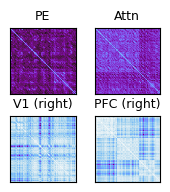

In [14]:
import matplotlib.pyplot as plt
from scipy.stats import zscore
import cmasher as cmr

def norm_mat(mat):
    values = mat[np.triu_indices(mat.shape[0], k=1)]
    norm_values = normalized = (values - values.min()) / (values.max() - values.min())
    #norm_values = zscore(values)
    plot_mat = np.zeros((mat.shape))
    plot_mat[np.triu_indices(mat.shape[0], k=1)] = norm_values
    plot_mat = plot_mat+plot_mat.T
    return plot_mat


plt.rcParams['svg.fonttype'] = 'none'

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(2, 2))
cmap = cmr.voltage_r

# PE
axes[0, 0].imshow(norm_mat(pe_avg_rdm), cmap=cmap, vmin=0, vmax=1)
axes[0, 0].set_title("PE", fontsize=9)
axes[0, 0].set_xticklabels([])
axes[0, 0].set_yticklabels([])
axes[0, 0].set_xticks([])
axes[0, 0].set_yticks([])

# Attention
axes[0, 1].imshow(norm_mat(attn_avg_rdm), cmap=cmap, vmin=0, vmax=1)
axes[0, 1].set_title("Attn", fontsize=9)
axes[0, 1].set_xticklabels([])
axes[0, 1].set_yticklabels([])
axes[0, 1].set_xticks([])
axes[0, 1].set_yticks([])

# empirical data R V1
roi = "R_V1_ROI"
print(roi)
rdm_file = f"../processed_data/fmri_rdms/"
rdm_file += f"method_{fmethod}_roi-{roi}.h5"
data = rsatoolbox.rdm.load_rdm(rdm_file).get_matrices()[0, :, :]
axes[1, 0].imshow(norm_mat(data), cmap=cmap, vmin=0, vmax=1)
axes[1, 0].set_title("V1 (right)", fontsize=9)
axes[1, 0].set_xticklabels([])
axes[1, 0].set_yticklabels([])
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])

# empirical data R_a47r_ROI
roi = "R_a47r_ROI"
print(roi)
rdm_file = f"../processed_data/fmri_rdms/"
rdm_file += f"method_{fmethod}_roi-{roi}.h5"
data = rsatoolbox.rdm.load_rdm(rdm_file).get_matrices()[0, :, :]
axes[1, 1].imshow(norm_mat(data), cmap=cmap, vmin=0, vmax=1)
axes[1, 1].set_title("PFC (right)", fontsize=9)
axes[1, 1].set_xticklabels([])
axes[1, 1].set_yticklabels([])
axes[1, 1].set_xticks([])
axes[1, 1].set_yticks([])
plt.subplots_adjust(hspace=0.35)
plt.show()

## Brain plots
This generates the figures as images which are loaded later in a nicely formatted grid.

In [ ]:
from lstnn.plotting import pub_surf_plot_contours, pub_surf_plot
def myround(x, base=0.05):
    return np.round(base * round(x/base), 2)

save = False
plot = False
cmap1 = cmr.sunburst
cmap2 = cmr.prinsenvlag_r
stats = ["stat"]#, "percentile"]
model = "pe_layer"
pe ="2dpe"
#lims = [(-.35, 0.35), (0, 1)]
plot_data = np.zeros((4, parc.n_parcels))

for model in ["mlp_layer"]:
    for layer in [0, 1, 2, 3]:
        for stat in stats:
            # suggested max val - changes across layers...
            #dmax = abs(max(df.loc[(df.pe == pe) & (df.model == model+"_"+str(layer)), stat].values)).round(2)

            # OR don't change across layers:
            dmax = abs(max(df.loc[(df.pe == pe) & (df.model.str.startswith(model)), stat].values)).round(2)
            d_max_round = myround(dmax)
            plot_data = df.loc[(df.pe == pe) & (df.model == model+str(layer)), stat].values
            plot_data2 = df.loc[(df.pe == pe) & (df.model == model+str(layer)), "p_FDR"].values
            c = 1
            for i in range(len(plot_data2)):
                if plot_data2[i] < 0.05:
                    plot_data2[i] = c
                    c = c+1
                else:
                    plot_data2[i] = 0
            if (cmethod == "corr") & (stat == "stat"):
                cmap = cmap2
            else:
                cmap = cmap1

            if (cmethod == "corr") & (stat == "stat"):
                vmin = d_max_round * -1
                vmax = d_max_round
            elif (cmethod == "cosine") & (stat == "stat"):
                vmin=None
                vmax=None
            else:
                vmin = 0
                vmax = 1
            vmin = -0.25
            vmax = 0.25
            if save:
                # pub_surf_plot(plot_data, parc.file, save=f"../figures/brain_plots/RSA-model-{model}_pe-{pe}_layer-{layer}_stat-{stat}", 
                #             size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)
                pub_surf_plot_contours(plot_data, plot_data2, parc.file, save=f"../processed_data/brain_plots/RSA-model-{model}{layer}_pe-{pe}_stat-{stat}_contoured", 
                            size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)
            if plot:
                print(model, stat)
                #pub_surf_plot(np.array(plot_data), parc.file, save=None, size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)
                pub_surf_plot_contours(np.array(plot_data), np.array(plot_data2), parc.file, save=None, size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)

# Four panel layer-by-layer figures
## MLP layers

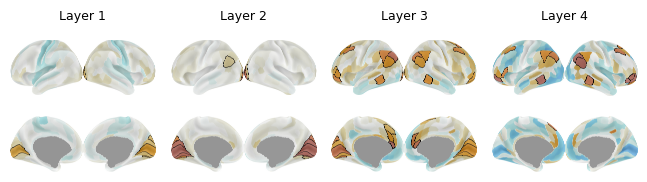

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lstnn.plotting import get_cropped_img
plt.rcParams['svg.fonttype'] = 'none'

# analysis params
stat = "stat"
pe ="2dpe"

# gridspec inside gridspec
fig = plt.figure(figsize=(8.1, 2))

# rows
rows = gridspec.GridSpec(2, 1, figure=fig, hspace=0, wspace=0, height_ratios=[0.01, 0.495*2])

# create gridspec between brains and scatter plot
cols = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=rows[0], hspace=0, wspace=0.1)
for layer in range(4):
    ax = fig.add_subplot(cols[layer])
    ax.set_title("Layer "+str(layer+1), fontsize=9)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    sns.despine(left=True, bottom=True, ax=ax)

# MLP brains
model = "mlp_layer"
cols = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=rows[1], hspace=0, wspace=0.1)

count = 0
for layer in range(0, 4):
    brain_grid = gridspec.GridSpecFromSubplotSpec(2, 2,
                                                  subplot_spec=cols[count],
                                                  hspace=0, wspace=0)
    b_count = 0
    for view in ['lateral', 'medial']:
        for hemi in ['left', 'right']:

            # get image
            img = plt.imread(
                f"../processed_data/brain_plots/RSA-model-{model}{layer}_pe-{pe}_stat-{stat}_contoured_{hemi}_{view}.jpeg")
            img_cropped = get_cropped_img(img,
                                          x_start_buffer=0,
                                          x_finish_buffer=0,
                                          y_start_buffer=0,
                                          y_finish_buffer=0)

            # get ax
            ax = fig.add_subplot(brain_grid[b_count])
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.imshow(img_cropped, aspect='equal', rasterized=True)
            sns.despine(left=True, bottom=True, ax=ax)
            b_count = b_count+1
    count = count+1
plt.show()

# Two panel: Average PE and ATTN

In [ ]:
def myround(x, base=0.05):
    return np.round(base * round(x/base), 2)

save = True
plot = False
cmap1 = cmr.sunburst
cmap2 = cmr.prinsenvlag_r
stats = ["stat"]#, "percentile"]
pe ="2dpe"
#lims = [(-.35, 0.35), (0, 1)]
plot_data = np.zeros((4, parc.n_parcels))

for model in ["pe_avg", "attn_out_avg"]:
    for stat in stats:
        # suggested max val - changes across layers...
        #dmax = abs(max(df.loc[(df.pe == pe) & (df.model == model+"_"+str(layer)), stat].values)).round(2)

        # OR don't change across layers:
        dmax = abs(max(df.loc[(df.pe == pe) & (df.model == model), stat].values)).round(3)
        d_max_round = myround(dmax)
        
        plot_data = df.loc[(df.pe == pe) & (df.model == model), stat].values
        plot_data2 = df.loc[(df.pe == pe) & (df.model == model), "p_FDR"].values
        c = 1
        for i in range(len(plot_data2)):
            if plot_data2[i] < 0.05:
                plot_data2[i] = c
                c = c+1
            else:
                plot_data2[i] = 0
        if (cmethod == "corr") & (stat == "stat"):
            cmap = cmap2
        else:
            cmap = cmap1

        if (cmethod == "corr") & (stat == "stat"):
            vmin = d_max_round * -1
            vmax = d_max_round
        elif (cmethod == "cosine") & (stat == "stat"):
            vmin=None
            vmax=None
        else:
            vmin = 0
            vmax = 1

        # actually, set some absolute limits for comparison
        vmax = 0.25
        vmin = -0.25
        
        if save:
            # pub_surf_plot(plot_data, parc.file, save=f"../figures/brain_plots/RSA-model-{model}_pe-{pe}_layer-{layer}_stat-{stat}", 
            #             size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)
            pub_surf_plot_contours(plot_data, plot_data2, parc.file, save=f"../processed_data/brain_plots/RSA-model-{model}_pe-{pe}_stat-{stat}_contoured", 
                        size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)
        if plot:
            print(model, stat)
            #pub_surf_plot(np.array(plot_data), parc.file, save=None, size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)
            pub_surf_plot_contours(np.array(plot_data), np.array(plot_data2), parc.file, save=None, size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)

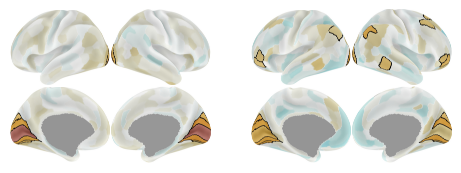

In [24]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.rcParams['svg.fonttype'] = 'none'

# analysis params
stat = "stat"
pe ="2dpe"

# gridspec inside gridspec
fig = plt.figure(figsize=(5.7, 2.0))

# create gridspec for cols
main_cols = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[0.5, 0.5], wspace=0.2)

for i, model in enumerate(["pe_avg", "attn_out_avg"]):
    brain_grid = gridspec.GridSpecFromSubplotSpec(2, 2,
                                                    subplot_spec=main_cols[i],
                                                    hspace=0.01, wspace=0.01)
    b_count = 0
    for view in ['lateral', 'medial']:
        for hemi in ['left', 'right']:

            # get image
            img = plt.imread(f"../processed_data/brain_plots/RSA-model-{model}_pe-{pe}_stat-{stat}_contoured_{hemi}_{view}.jpeg")
            img_cropped = get_cropped_img(img,
                                            x_start_buffer=0,
                                            x_finish_buffer=0,
                                            y_start_buffer=0,
                                            y_finish_buffer=0)

            # get ax
            ax = fig.add_subplot(brain_grid[b_count])
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.imshow(img_cropped, aspect='equal', rasterized=True)
            sns.despine(left=True, bottom=True, ax=ax)
            b_count = b_count+1
plt.show()

# Untrained models

In [27]:
# parameters
pe_desc = "2dpe"
epoch = 0
n_perms = 10000

df_list = []
in_file = f"../processed_data/pe-{pe_desc}"
in_file += f"_fmethod-{fmethod}_amethod-{amethod}_cmethod-{cmethod}"
in_file += f"_epoch-{epoch}_nperms-{n_perms}"

#df_all = pd.read_csv(in_file+".csv")
df = pd.read_csv(in_file+"_stats.csv")
df.head()

data = df.loc[((df.model == "pe_avg") | (df.model == "attn_out_avg"))
              & (df.p_FDR < 0.05)]
results = data[["model", "parcel", "network", "stat", "p_FDR"]]

results.replace("pe_avg", "PE", inplace=True)
results.replace("attn_out_avg", "Attention", inplace=True)
results = results.sort_values(by=["model", "network"])
results["stat"] = np.round(results["stat"],3)
results["p_FDR"] = np.round(results["p_FDR"],4)
results.head()

/tmp/ipykernel_1210821/2256710436.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results.replace("pe_avg", "PE", inplace=True)
/tmp/ipykernel_1210821/2256710436.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results.replace("attn_out_avg", "Attention", inplace=True)


,model,parcel,network,stat,p_FDR
244,PE,R_V1_ROI,Visual1,0.168,0.0


In [28]:
def myround(x, base=0.05):
    return np.round(base * round(x/base), 2)

save = True
plot = False
cmap1 = cmr.sunburst
cmap2 = cmr.prinsenvlag_r
stats = ["stat"]#, "percentile"]
pe ="2dpe"
#lims = [(-.35, 0.35), (0, 1)]
plot_data = np.zeros((4, parc.n_parcels))

for model in ["pe_avg", "attn_out_avg"]:
    for stat in stats:
        # suggested max val - changes across layers...
        #dmax = abs(max(df.loc[(df.pe == pe) & (df.model == model+"_"+str(layer)), stat].values)).round(2)

        # OR don't change across layers:
        dmax = abs(max(df.loc[(df.pe == pe) & (df.model == model), stat].values)).round(3)
        d_max_round = myround(dmax)

        plot_data = df.loc[(df.pe == pe) & (df.model == model), stat].values
        plot_data2 = df.loc[(df.pe == pe) & (df.model == model), "p_FDR"].values
        c = 1
        for i in range(len(plot_data2)):
            if plot_data2[i] < 0.05:
                plot_data2[i] = c
                c = c+1
            else:
                plot_data2[i] = 0
        if (cmethod == "corr") & (stat == "stat"):
            cmap = cmap2
        else:
            cmap = cmap1

        if (cmethod == "corr") & (stat == "stat"):
            vmin = d_max_round * -1
            vmax = d_max_round
        elif (cmethod == "cosine") & (stat == "stat"):
            vmin=None
            vmax=None
        else:
            vmin = 0
            vmax = 1

        # actually, set some absolute limits for comparison
        vmax = 0.25
        vmin = -0.25
        
        if save:
            # pub_surf_plot(plot_data, parc.file, save=f"../figures/brain_plots/RSA-model-{model}_pe-{pe}_layer-{layer}_stat-{stat}", 
            #             size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)
            pub_surf_plot_contours(plot_data, plot_data2, parc.file, save=f"../processed_data/brain_plots/RSA_untrained-model-{model}_pe-{pe}_stat-{stat}_contoured", 
                        size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)
        if plot:
            print(model, stat)
            #pub_surf_plot(np.array(plot_data), parc.file, save=None, size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)
            pub_surf_plot_contours(np.array(plot_data), np.array(plot_data2), parc.file, save=None, size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)

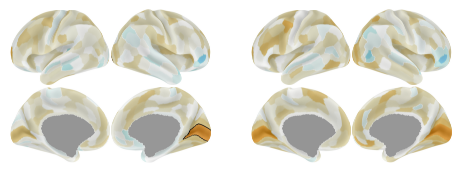

In [29]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.rcParams['svg.fonttype'] = 'none'

# analysis params
stat = "stat"
pe ="2dpe"

# gridspec inside gridspec
fig = plt.figure(figsize=(5.7, 2.0))

# create gridspec for cols
main_cols = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[0.5, 0.5], wspace=0.2)

for i, model in enumerate(["pe_avg", "attn_out_avg"]):
    brain_grid = gridspec.GridSpecFromSubplotSpec(2, 2,
                                                    subplot_spec=main_cols[i],
                                                    hspace=0.01, wspace=0.01)
    b_count = 0
    for view in ['lateral', 'medial']:
        for hemi in ['left', 'right']:

            # get image
            img = plt.imread(f"../processed_data/brain_plots/RSA_untrained-model-{model}_pe-{pe}_stat-{stat}_contoured_{hemi}_{view}.jpeg")
            img_cropped = get_cropped_img(img,
                                            x_start_buffer=0,
                                            x_finish_buffer=0,
                                            y_start_buffer=0,
                                            y_finish_buffer=0)

            # get ax
            ax = fig.add_subplot(brain_grid[b_count])
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.imshow(img_cropped, aspect='equal', rasterized=True)
            sns.despine(left=True, bottom=True, ax=ax)
            b_count = b_count+1
plt.show()